### Required Assignment 5.1: Will the Customer Accept the Coupon?

**Context**

Imagine driving through town and a coupon is delivered to your cell phone for a restaurant near where you are driving. Would you accept that coupon and take a short detour to the restaurant? Would you accept the coupon but use it on a subsequent trip? Would you ignore the coupon entirely? What if the coupon was for a bar instead of a restaurant? What about a coffee house? Would you accept a bar coupon with a minor passenger in the car? What about if it was just you and your partner in the car? Would weather impact the rate of acceptance? What about the time of day?

Obviously, proximity to the business is a factor on whether the coupon is delivered to the driver or not, but what are the factors that determine whether a driver accepts the coupon once it is delivered to them? How would you determine whether a driver is likely to accept a coupon?

**Overview**

The goal of this project is to use what you know about visualizations and probability distributions to distinguish between customers who accepted a driving coupon versus those that did not.

**Data**

This data comes to us from the UCI Machine Learning repository and was collected via a survey on Amazon Mechanical Turk. The survey describes different driving scenarios including the destination, current time, weather, passenger, etc., and then ask the person whether he will accept the coupon if he is the driver. Answers that the user will drive there ‘right away’ or ‘later before the coupon expires’ are labeled as ‘Y = 1’ and answers ‘no, I do not want the coupon’ are labeled as ‘Y = 0’.  There are five different types of coupons -- less expensive restaurants (under \$20), coffee houses, carry out & take away, bar, and more expensive restaurants (\$20 - $50).

**Deliverables**

Your final product should be a brief report that highlights the differences between customers who did and did not accept the coupons.  To explore the data you will utilize your knowledge of plotting, statistical summaries, and visualization using Python. You will publish your findings in a public facing github repository as your first portfolio piece.





### Data Description
Keep in mind that these values mentioned below are average values.

The attributes of this data set include:
1. User attributes
    -  Gender: male, female
    -  Age: below 21, 21 to 25, 26 to 30, etc.
    -  Marital Status: single, married partner, unmarried partner, or widowed
    -  Number of children: 0, 1, or more than 1
    -  Education: high school, bachelors degree, associates degree, or graduate degree
    -  Occupation: architecture & engineering, business & financial, etc.
    -  Annual income: less than \\$12500, \\$12500 - \\$24999, \\$25000 - \\$37499, etc.
    -  Number of times that he/she goes to a bar: 0, less than 1, 1 to 3, 4 to 8 or greater than 8
    -  Number of times that he/she buys takeaway food: 0, less than 1, 1 to 3, 4 to 8 or greater
    than 8
    -  Number of times that he/she goes to a coffee house: 0, less than 1, 1 to 3, 4 to 8 or
    greater than 8
    -  Number of times that he/she eats at a restaurant with average expense less than \\$20 per
    person: 0, less than 1, 1 to 3, 4 to 8 or greater than 8
    -  Number of times that he/she goes to a bar: 0, less than 1, 1 to 3, 4 to 8 or greater than 8
    

2. Contextual attributes
    - Driving destination: home, work, or no urgent destination
    - Location of user, coupon and destination: we provide a map to show the geographical
    location of the user, destination, and the venue, and we mark the distance between each
    two places with time of driving. The user can see whether the venue is in the same
    direction as the destination.
    - Weather: sunny, rainy, or snowy
    - Temperature: 30F, 55F, or 80F
    - Time: 10AM, 2PM, or 6PM
    - Passenger: alone, partner, kid(s), or friend(s)


3. Coupon attributes
    - time before it expires: 2 hours or one day

In [24]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
import plotly.express as px

### Problems

Use the prompts below to get started with your data analysis.  

1. Read in the `coupons.csv` file.




In [7]:
data = pd.read_csv('data/coupons.csv')

In [8]:
data

,destination,passanger,weather,temperature,time,coupon,expiration,gender,age,maritalStatus,...,CoffeeHouse,CarryAway,RestaurantLessThan20,Restaurant20To50,toCoupon_GEQ5min,toCoupon_GEQ15min,toCoupon_GEQ25min,direction_same,direction_opp,Y
0,No Urgent Place,Alone,Sunny,55,2PM,Restaurant(<20),1d,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,0,0,0,1,1
1,No Urgent Place,Friend(s),Sunny,80,10AM,Coffee House,2h,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,0,0,0,1,0
2,No Urgent Place,Friend(s),Sunny,80,10AM,Carry out & Take away,2h,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,1,0,0,1,1
3,No Urgent Place,Friend(s),Sunny,80,2PM,Coffee House,2h,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,1,0,0,1,0
4,No Urgent Place,Friend(s),Sunny,80,2PM,Coffee House,1d,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,1,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12679,Home,Partner,Rainy,55,6PM,Carry out & Take away,1d,Male,26,Single,...,never,1~3,4~8,1~3,1,0,0,1,0,1
12680,Work,Alone,Rainy,55,7AM,Carry out & Take away,1d,Male,26,Single,...,never,1~3,4~8,1~3,1,0,0,0,1,1
12681,Work,Alone,Snowy,30,7AM,Coffee House,1d,Male,26,Single,...,never,1~3,4~8,1~3,1,0,0,1,0,0
12682,Work,Alone,Snowy,30,7AM,Bar,1d,Male,26,Single,...,never,1~3,4~8,1~3,1,1,1,0,1,0


2. Investigate the dataset for missing or problematic data.

In [9]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12684 entries, 0 to 12683
Data columns (total 26 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   destination           12684 non-null  object
 1   passanger             12684 non-null  object
 2   weather               12684 non-null  object
 3   temperature           12684 non-null  int64 
 4   time                  12684 non-null  object
 5   coupon                12684 non-null  object
 6   expiration            12684 non-null  object
 7   gender                12684 non-null  object
 8   age                   12684 non-null  object
 9   maritalStatus         12684 non-null  object
 10  has_children          12684 non-null  int64 
 11  education             12684 non-null  object
 12  occupation            12684 non-null  object
 13  income                12684 non-null  object
 14  car                   108 non-null    object
 15  Bar                   12577 non-null

In [10]:
data.count()

destination             12684
passanger               12684
weather                 12684
temperature             12684
time                    12684
coupon                  12684
expiration              12684
gender                  12684
age                     12684
maritalStatus           12684
has_children            12684
education               12684
occupation              12684
income                  12684
car                       108
Bar                     12577
CoffeeHouse             12467
CarryAway               12533
RestaurantLessThan20    12554
Restaurant20To50        12495
toCoupon_GEQ5min        12684
toCoupon_GEQ15min       12684
toCoupon_GEQ25min       12684
direction_same          12684
direction_opp           12684
Y                       12684
dtype: int64

In [11]:
missing_values = data.isnull().sum()
missing_values

destination                 0
passanger                   0
weather                     0
temperature                 0
time                        0
coupon                      0
expiration                  0
gender                      0
age                         0
maritalStatus               0
has_children                0
education                   0
occupation                  0
income                      0
car                     12576
Bar                       107
CoffeeHouse               217
CarryAway                 151
RestaurantLessThan20      130
Restaurant20To50          189
toCoupon_GEQ5min            0
toCoupon_GEQ15min           0
toCoupon_GEQ25min           0
direction_same              0
direction_opp               0
Y                           0
dtype: int64

3. Decide what to do about your missing data -- drop, replace, other...

In [12]:
# Dropping the car column because it has around 12576 from total 12684 values missing
data = data.drop(columns=['car'])

# Renaming the column "passanger" to "passenger" to fix typo error
data.rename(columns={'passanger': 'passenger'}, inplace=True)

In [13]:
# Filling all null values with placeholder "unspecified"
data.fillna("unspecified", inplace=True)

# verify that invalid values are now filled
data.isnull().sum()

destination             0
passenger               0
weather                 0
temperature             0
time                    0
coupon                  0
expiration              0
gender                  0
age                     0
maritalStatus           0
has_children            0
education               0
occupation              0
income                  0
Bar                     0
CoffeeHouse             0
CarryAway               0
RestaurantLessThan20    0
Restaurant20To50        0
toCoupon_GEQ5min        0
toCoupon_GEQ15min       0
toCoupon_GEQ25min       0
direction_same          0
direction_opp           0
Y                       0
dtype: int64

4. What proportion of the total observations chose to accept the coupon?



In [14]:
# To get the percentage who chose to accept the coupon 
accepted_proportion = data['Y'].value_counts(normalize=True)[1] * 100
print(f"Coupon accpetance proportion percentage: {accepted_proportion:.2f}%")

Coupon accpetance proportion percentage: 56.84%


5. Use a bar plot to visualize the `coupon` column.

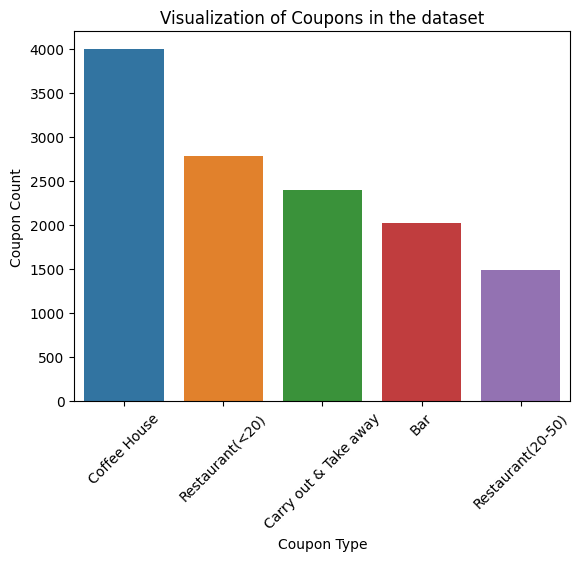

In [15]:
coupon_counts = data['coupon'].value_counts().reset_index()
sns.barplot(data=coupon_counts, x='coupon', y='count', hue='coupon')
plt.title('Visualization of Coupons in the dataset')
plt.xlabel('Coupon Type')
plt.ylabel('Coupon Count')
plt.xticks(rotation=45)
plt.show()

6. Use a histogram to visualize the temperature column.

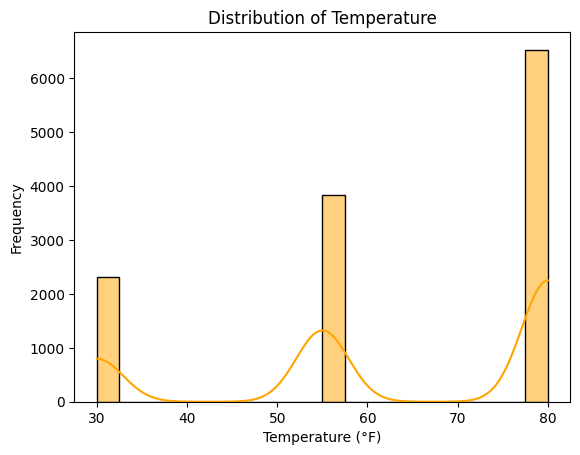

In [16]:
sns.histplot(data, x='temperature', bins=20, kde=True, color='orange')
plt.title('Distribution of Temperature')
plt.xlabel('Temperature (°F)')
plt.ylabel('Frequency')
plt.show()

**Investigating the Bar Coupons**

Now, we will lead you through an exploration of just the bar related coupons.  

1. Create a new `DataFrame` that contains just the bar coupons.


In [17]:
bar_coupons = data[data['coupon'] == 'Bar']
bar_coupons

,destination,passenger,weather,temperature,time,coupon,expiration,gender,age,maritalStatus,...,CoffeeHouse,CarryAway,RestaurantLessThan20,Restaurant20To50,toCoupon_GEQ5min,toCoupon_GEQ15min,toCoupon_GEQ25min,direction_same,direction_opp,Y
9,No Urgent Place,Kid(s),Sunny,80,10AM,Bar,1d,Female,21,Unmarried partner,...,never,unspecified,4~8,1~3,1,1,0,0,1,0
13,Home,Alone,Sunny,55,6PM,Bar,1d,Female,21,Unmarried partner,...,never,unspecified,4~8,1~3,1,0,0,1,0,1
17,Work,Alone,Sunny,55,7AM,Bar,1d,Female,21,Unmarried partner,...,never,unspecified,4~8,1~3,1,1,1,0,1,0
24,No Urgent Place,Friend(s),Sunny,80,10AM,Bar,1d,Male,21,Single,...,less1,4~8,4~8,less1,1,0,0,0,1,1
35,Home,Alone,Sunny,55,6PM,Bar,1d,Male,21,Single,...,less1,4~8,4~8,less1,1,0,0,1,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12663,No Urgent Place,Friend(s),Sunny,80,10PM,Bar,1d,Male,26,Single,...,never,1~3,4~8,1~3,1,1,0,0,1,0
12664,No Urgent Place,Friend(s),Sunny,55,10PM,Bar,2h,Male,26,Single,...,never,1~3,4~8,1~3,1,1,0,0,1,0
12667,No Urgent Place,Alone,Rainy,55,10AM,Bar,1d,Male,26,Single,...,never,1~3,4~8,1~3,1,1,0,0,1,0
12670,No Urgent Place,Partner,Rainy,55,6PM,Bar,2h,Male,26,Single,...,never,1~3,4~8,1~3,1,1,0,0,1,0


2. What proportion of bar coupons were accepted?


In [18]:
percent_accepted = bar_coupons['Y'].value_counts(normalize=True)[1] * 100
print(f"Bar Coupon accpetance percentage: {percent_accepted:.2f}%")

Bar Coupon accpetance percentage: 41.00%


3. Compare the acceptance rate between those who went to a bar 3 or fewer times a month to those who went more.


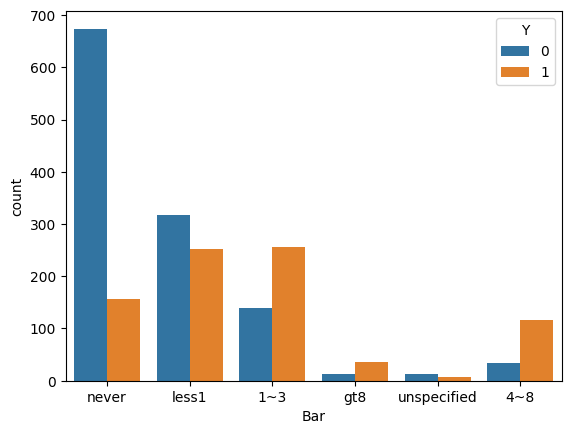

In [19]:
# Quick visualization of Bar Coupons overall acceptance per category
sns.countplot(bar_coupons,x='Bar',hue='Y')
plt.show()

In [20]:
# Print distinct values for bar
print(bar_coupons['Bar'].unique().tolist())


['never', 'less1', '1~3', 'gt8', 'unspecified', '4~8']


In [21]:
# Rate of going 3 times or less in a month
less_than_3_bar_goers = bar_coupons.query("Bar in ['never', 'less1', '1~3']")
rate_less_than_3_bar_goers = less_than_3_bar_goers['Y'].mean()

# Rate of going more than 3 times in a month
more_than_3_bar_goers = bar_coupons.query("Bar in ['4~8', 'gt8']")
rate_more_than_3_bar_goers = more_than_3_bar_goers['Y'].mean()

# Getting the Acceptance rate
print(f"Acceptance rate of going 3 times or less in a month : {rate_less_than_3_bar_goers:.2%}")
print(f"Acceptance rate of going more than 3 times in a month:  {rate_more_than_3_bar_goers:.2%}")


Acceptance rate of going 3 times or less in a month : 37.06%
Acceptance rate of going more than 3 times in a month:  76.88%


In [26]:
# Plotly Visualization
data = {
    'Bar Visit Frequency': ['3 times or less', 'More than 3 times'],
    'Acceptance Rate %': [rate_less_than_3_bar_goers * 100, rate_more_than_3_bar_goers * 100]
}

fig = px.bar(
    data, 
    x='Bar Visit Frequency', 
    y='Acceptance Rate %',
    title='Bar Coupon Acceptance Rate by Visit Frequency'
)
fig.show()

![Bar Plot 1](bar_coupon_plot1.png)

4. Compare the acceptance rate between drivers who go to a bar more than once a month and are over the age of 25 to the all others.  Is there a difference?


In [107]:
# Print distinct values for bar and age
print(bar_coupons['Bar'].unique().tolist())
print(bar_coupons['age'].unique().tolist())

['never', 'less1', '1~3', 'gt8', 'unspecified', '4~8']
['21', '46', '26', '31', '41', '50plus', '36', 'below21']


In [103]:
# Rate between drivers going to bar more than once a month and over age 25
bar_going_drivers_more_than_once = bar_coupons.query("Bar in ['1~3', 'gt8','4~8'] and age in ['46', '26', '31', '41', '50plus', '36']")
rate_bar_going_drivers_more_than_once = bar_going_drivers_more_than_once['Y'].mean()

# Rate of others
all_other_drivers = bar_coupons.query("not (Bar in ['1~3', 'gt8','4~8'] and age in ['46', '26', '31', '41', '50plus', '36'])")
rate_all_other_drivers = all_other_drivers['Y'].mean()

# Getting the Acceptance rate
print(f"Acceptance rate between drivers going to bar more than once a month and over age 25 : {rate_bar_going_drivers_more_than_once:.2%}")
print(f"Acceptance rate of others:  {rate_all_other_drivers:.2%}")

Acceptance rate between drivers going to bar more than once a month and over age 25 : 69.52%
Acceptance rate of others:  33.50%


In [ ]:
# Plotly Visualization
data = {
    'Bar Visit Frequency by Driver Age': ['More than once a month and over age 25', 'All others'],
    'Acceptance Rate %': [rate_bar_going_drivers_more_than_once * 100 , rate_all_other_drivers * 100]
}

fig = px.bar(
    data, 
    x='Bar Visit Frequency by Driver Age', 
    y='Acceptance Rate %',
    title='Bar Coupon Acceptance Rate Visit Frequency by Driver Age'
)
fig.show()

5. Use the same process to compare the acceptance rate between drivers who go to bars more than once a month and had passengers that were not a kid and had occupations other than farming, fishing, or forestry.


In [110]:
# Print distinct values for Bar,passenger and occupation
print(bar_coupons['Bar'].unique().tolist())
print(bar_coupons['passenger'].unique().tolist())
print(bar_coupons['occupation'].unique().tolist())

['never', 'less1', '1~3', 'gt8', 'unspecified', '4~8']
['Kid(s)', 'Alone', 'Friend(s)', 'Partner']
['Unemployed', 'Architecture & Engineering', 'Student', 'Education&Training&Library', 'Healthcare Support', 'Healthcare Practitioners & Technical', 'Sales & Related', 'Management', 'Arts Design Entertainment Sports & Media', 'Computer & Mathematical', 'Life Physical Social Science', 'Personal Care & Service', 'Community & Social Services', 'Office & Administrative Support', 'Construction & Extraction', 'Legal', 'Retired', 'Installation Maintenance & Repair', 'Transportation & Material Moving', 'Business & Financial', 'Protective Service', 'Food Preparation & Serving Related', 'Production Occupations', 'Building & Grounds Cleaning & Maintenance', 'Farming Fishing & Forestry']


In [142]:
# Excluded list as per criteria
excluded_criteria_list = bar_coupons.query("Bar in ['1~3', 'gt8','4~8'] and passenger not in ['Kid(s)'] and occupation not in ['Farming Fishing & Forestry']")
excluded_criteria_list_rate = excluded_criteria_list['Y'].mean()

# All others
all_others = bar_coupons.query("not (Bar in ['1~3', 'gt8','4~8'] and passenger not in ['Kid(s)'] and occupation not in ['Farming Fishing & Forestry'])")
all_others_rate = all_others['Y'].mean()

print(f"Acceptance rate between drivers who go to bars more than once a month and had passengers that were not a kid and had occupations other than farming, fishing, or forestry. : {excluded_criteria_list_rate:.2%}")
print(f"All Others Acceptance Rate: {all_others_rate:.2%}")

Acceptance rate between drivers who go to bars more than once a month and had passengers that were not a kid and had occupations other than farming, fishing, or forestry. : 71.32%
All Others Acceptance Rate: 29.60%


In [ ]:
# Plotly Visualization
data = {
    'Bar Visit Frequency by Passenger Occupation': ['Monthly more than once excluding kid and farming, fishing, or forestry occupation' , 'All others'],
    'Acceptance Rate %': [excluded_criteria_list_rate * 100 , all_others_rate * 100]
}

fig = px.bar(
    data, 
    x='Bar Visit Frequency by Passenger Occupation', 
    y='Acceptance Rate %',
    title='Bar Coupon Acceptance Rate Visit Frequency by Passenger Occupation'
)
fig.show()

6. Compare the acceptance rates between those drivers who:

- go to bars more than once a month, had passengers that were not a kid, and were not widowed *OR*
- go to bars more than once a month and are under the age of 30 *OR*
- go to cheap restaurants more than 4 times a month and income is less than 50K.



In [5]:
# Print distinct values for Bar,passenger and occupation
print(bar_coupons['Bar'].unique().tolist())
print(bar_coupons['passenger'].unique().tolist())
print(bar_coupons['maritalStatus'].unique().tolist())
print(bar_coupons['age'].unique().tolist())
print(bar_coupons['income'].unique().tolist())

NameError: name 'bar_coupons' is not defined

In [149]:
bar_visit_frequency = ['1~3', '4~8', 'gt8']
passenger_excluded = ['Kid(s)']
below_30 = ['below21', '21', '26']

cheap_restaurant_visit_frequency = ['4~8', 'gt8']
income_below_50k = ['Less rather than $12500', '$12500 - $24999', '$25000 - $37499', '$37499 - $49999']

question_1 = "(Bar in @bar_visit_frequency and passenger not in @passenger_excluded and maritalStatus != 'Widowed')"
question_2 = "(Bar in @bar_visit_frequency and age in @below_30)"
question_3 = "(RestaurantLessThan20 in @cheap_restaurant_visit_frequency and income in @income_below_50k)"

target_question = f"{question_1} or {question_2} or {question_3}"

targeted_group = bar_coupons.query(target_question)
all_others   = bar_coupons.query(f"not ({target_question})")

targeted_group_rate = targeted_group['Y'].mean()
all_others_rate = all_others['Y'].mean()

print(f"Target Group Acceptance Rate: {targeted_group_rate:.2%}")
print(f"All Others Acceptance Rate: {all_others_rate:.2%}")

Target Group Acceptance Rate: 64.25%
All Others Acceptance Rate: 29.62%


In [4]:
# Plotly Visualization
data = {
    'Bar Visit Frequency by Different Target groups': ['Target Group Acceptance Rate' , 'All others'],
    'Acceptance Rate %': [targeted_group_rate * 100 , all_others_rate * 100]
}

fig = px.bar(
    data, 
    x='Bar Visit Frequency by Different Target groups', 
    y='Acceptance Rate %',
    title='Bar Coupon Acceptance Rate Visit Frequency by Target Groups'
)
fig.show()

NameError: name 'targeted_group_rate' is not defined

7.  Based on these observations, what do you hypothesize about drivers who accepted the bar coupons?

1. People stick to their habits: Regular bar goers accepted the coupon at double the rate of people who rarely go.
2. Who is in the car matters most: People are happy to detour to a bar if they are alone or out with friends, but if a child is in the car, the coupon gets rejected, no matter how much the driver likes to go to bars.
3. Age demographics : The absolute best target is someone under 30 who already goes out a lot. They view the coupon as a perfect excuse to keep the night going.
4. Lower income priorities : People with lower incomes who love cheap restaurants like discounts, but they still do not care for bars. Offering them a bar coupon is a mismatch of their habits.

### Independent Investigation

Using the bar coupon example as motivation, you are to explore one of the other coupon groups and try to determine the characteristics of passengers who accept the coupons.  

We will investigate and get results for "Carry and Takeout Coupon" for below question

1.Buy carry-out food more than once a month, are driving without kids, and their marital status is not widowed. OR
2.Buy carry-out food more than once a month and are under the age of 30. OR
3.Go to cheap restaurants more than 4 times a month and have an income under $50,000.

Create a DataFrame that only contains "CarryAway" coupons

In [ ]:
# Reading data, creating dataframe and cleaning as required
data_df = pd.read_csv('data/coupons.csv')
# Dropping the car column because it has more missing values
data_df = data_df.drop(columns=['car'])

# Renaming the column "passanger" to "passenger" to fix typo error
data_df.rename(columns={'passanger': 'passenger'}, inplace=True)

# Filling all null values with placeholder "unspecified"
data_df.fillna("unspecified", inplace=True)

# verify that invalid values are now filled
data_df.isnull().sum()

carry_away_coupons = data_df[data_df['coupon'] == 'Carry out & Take away']
carry_away_coupons

,destination,passenger,weather,temperature,time,coupon,expiration,gender,age,maritalStatus,...,CoffeeHouse,CarryAway,RestaurantLessThan20,Restaurant20To50,toCoupon_GEQ5min,toCoupon_GEQ15min,toCoupon_GEQ25min,direction_same,direction_opp,Y
2,No Urgent Place,Friend(s),Sunny,80,10AM,Carry out & Take away,2h,Female,21,Unmarried partner,...,never,unspecified,4~8,1~3,1,1,0,0,1,1
6,No Urgent Place,Friend(s),Sunny,55,2PM,Carry out & Take away,1d,Female,21,Unmarried partner,...,never,unspecified,4~8,1~3,1,1,0,0,1,1
8,No Urgent Place,Kid(s),Sunny,80,10AM,Carry out & Take away,2h,Female,21,Unmarried partner,...,never,unspecified,4~8,1~3,1,1,0,0,1,1
19,Work,Alone,Sunny,80,7AM,Carry out & Take away,2h,Female,21,Unmarried partner,...,never,unspecified,4~8,1~3,1,0,0,1,0,1
25,No Urgent Place,Friend(s),Sunny,80,10AM,Carry out & Take away,2h,Male,21,Single,...,less1,4~8,4~8,less1,1,1,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12665,No Urgent Place,Friend(s),Sunny,30,10AM,Carry out & Take away,2h,Male,26,Single,...,never,1~3,4~8,1~3,1,0,0,0,1,1
12672,Home,Alone,Sunny,80,6PM,Carry out & Take away,2h,Male,26,Single,...,never,1~3,4~8,1~3,1,1,0,1,0,0
12673,Home,Alone,Sunny,30,6PM,Carry out & Take away,1d,Male,26,Single,...,never,1~3,4~8,1~3,1,0,0,0,1,0
12679,Home,Partner,Rainy,55,6PM,Carry out & Take away,1d,Male,26,Single,...,never,1~3,4~8,1~3,1,0,0,1,0,1


In [162]:
carry_away_visit_frequency = ['1~3', '4~8', 'gt8']
passenger_excluded = ['Kid(s)']
below_30 = ['below21', '21', '26']

cheap_restaurant_visit_frequency = ['4~8', 'gt8']
income_below_50k = ['Less rather than $12500', '$12500 - $24999', '$25000 - $37499', '$37499 - $49999']

question_1 = "(CarryAway in @carry_away_visit_frequency and passenger not in @passenger_excluded and maritalStatus != 'Widowed')"
question_2 = "(CarryAway in @carry_away_visit_frequency and age in @below_30)"
question_3 = "(RestaurantLessThan20 in @cheap_restaurant_visit_frequency and income in @income_below_50k)"

target_question = f"{question_1} or {question_2} or {question_3}"

targeted_group = carry_away_coupons.query(target_question)
all_others   = carry_away_coupons.query(f"not ({target_question})")

targeted_group_rate = targeted_group['Y'].mean()
all_others_rate = all_others['Y'].mean()

print(f"Target Group Acceptance Rate: {targeted_group_rate:.2%}")
print(f"All Others Acceptance Rate: {all_others_rate:.2%}")

Target Group Acceptance Rate: 74.43%
All Others Acceptance Rate: 70.16%


In [ ]:
# Plotly Visualization
data = {
    'Carry Out Visit Frequency by Different Target groups': ['Target Group Acceptance Rate' , 'All others'],
    'Acceptance Rate %': [targeted_group_rate * 100 , all_others_rate * 100]
}

fig = px.bar(
    data, 
    x='Carry Out Visit Frequency by Different Target groups', 
    y='Acceptance Rate %',
    title='Carry out Coupon Acceptance Rate Visit Frequency by Target Groups'
)
fig.show()

As compared to Bar Coupon, we see no difference between the same targeted group and the conversion rate is only 4% between all others in regards to Carry Out coupon usage.

Now comapring the same with Coffee coupon

1.Buy carry-out food more than once a month, are driving without kids, and their marital status is not widowed. OR
2.Buy carry-out food more than once a month and are under the age of 30. OR
3.Go to cheap restaurants more than 4 times a month and have an income under $50,000.

In [167]:
# Reading data, creating dataframe and cleaning as required
data_df = pd.read_csv('data/coupons.csv')
# Dropping the car column because it has more missing values
data_df = data_df.drop(columns=['car'])

# Renaming the column "passanger" to "passenger" to fix typo error
data_df.rename(columns={'passanger': 'passenger'}, inplace=True)

# Filling all null values with placeholder "unspecified"
data_df.fillna("unspecified", inplace=True)

# verify that invalid values are now filled
data_df.isnull().sum()

coffee_coupons = data_df[data_df['coupon'] == 'Coffee House']
coffee_coupons

,destination,passenger,weather,temperature,time,coupon,expiration,gender,age,maritalStatus,...,CoffeeHouse,CarryAway,RestaurantLessThan20,Restaurant20To50,toCoupon_GEQ5min,toCoupon_GEQ15min,toCoupon_GEQ25min,direction_same,direction_opp,Y
1,No Urgent Place,Friend(s),Sunny,80,10AM,Coffee House,2h,Female,21,Unmarried partner,...,never,unspecified,4~8,1~3,1,0,0,0,1,0
3,No Urgent Place,Friend(s),Sunny,80,2PM,Coffee House,2h,Female,21,Unmarried partner,...,never,unspecified,4~8,1~3,1,1,0,0,1,0
4,No Urgent Place,Friend(s),Sunny,80,2PM,Coffee House,1d,Female,21,Unmarried partner,...,never,unspecified,4~8,1~3,1,1,0,0,1,0
12,No Urgent Place,Kid(s),Sunny,55,6PM,Coffee House,2h,Female,21,Unmarried partner,...,never,unspecified,4~8,1~3,1,1,0,0,1,1
15,Home,Alone,Sunny,80,6PM,Coffee House,2h,Female,21,Unmarried partner,...,never,unspecified,4~8,1~3,1,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12656,Home,Alone,Snowy,30,10PM,Coffee House,2h,Male,31,Married partner,...,never,4~8,gt8,less1,1,1,0,0,1,0
12659,Work,Alone,Snowy,30,7AM,Coffee House,1d,Male,31,Married partner,...,never,4~8,gt8,less1,1,0,0,1,0,0
12674,Home,Alone,Rainy,55,10PM,Coffee House,2h,Male,26,Single,...,never,1~3,4~8,1~3,1,0,0,1,0,0
12675,Home,Alone,Snowy,30,10PM,Coffee House,2h,Male,26,Single,...,never,1~3,4~8,1~3,1,1,0,0,1,0


In [3]:
coffee_house_visit_frequency = ['1~3', '4~8', 'gt8']
passenger_excluded = ['Kid(s)']
below_30 = ['below21', '21', '26']

cheap_restaurant_visit_frequency = ['4~8', 'gt8']
income_below_50k = ['Less rather than $12500', '$12500 - $24999', '$25000 - $37499', '$37499 - $49999']

question_1 = "(CoffeeHouse in @coffee_house_visit_frequency and passenger not in @passenger_excluded and maritalStatus != 'Widowed')"
question_2 = "(CoffeeHouse in @coffee_house_visit_frequency and age in @below_30)"
question_3 = "(RestaurantLessThan20 in @cheap_restaurant_visit_frequency and income in @income_below_50k)"

target_question = f"{question_1} or {question_2} or {question_3}"

targeted_group = coffee_coupons.query(target_question)
all_others   = coffee_coupons.query(f"not ({target_question})")

targeted_group_rate = targeted_group['Y'].mean()
all_others_rate = all_others['Y'].mean()

print(f"Target Group Acceptance Rate: {targeted_group_rate:.2%}")
print(f"All Others Acceptance Rate: {all_others_rate:.2%}")

NameError: name 'coffee_coupons' is not defined

In [ ]:
# Plotly Visualization
data = {
    'Coffee House Visit Frequency by Different Target groups': ['Target Group Acceptance Rate' , 'All others'],
    'Acceptance Rate %': [targeted_group_rate * 100 , all_others_rate * 100]
}

fig = px.bar(
    data, 
    x='Coffee House Visit Frequency by Different Target groups', 
    y='Acceptance Rate %',
    title='Coffee House Coupon Acceptance Rate Visit Frequency by Target Groups'
)
fig.show()

NameError: name 'targeted_group_rate' is not defined

Looks much similar to Bar coupon and the targeted group should be looked upon since they have a better chance of using the Coffee House Coupon